# 00b_2D_generate_benchmark_function_with_z_noise

## Cel notebooka

Ten notebook definiuje i diagnozuje **dwuwymiarową funkcję benchmarkową** przeznaczoną do późniejszych eksperymentów z aproksymacją powierzchni, w szczególności z 2D P-splajnami i wariantami z ograniczeniami kształtu.

Notebook nie wykonuje jeszcze dopasowania modelu. Jego celem jest przygotowanie referencyjnej funkcji:

$$
z=f(x,y)
$$

oraz analitycznych wartości pochodnych:

$$
\frac{\partial f}{\partial x},
\qquad
\frac{\partial f}{\partial y},
\qquad
\frac{\partial^2 f}{\partial x^2},
\qquad
\frac{\partial^2 f}{\partial x\partial y},
\qquad
\frac{\partial^2 f}{\partial y^2}.
$$

Notebook generuje również:

- `std_z` — metrologiczne odchylenie standardowe pomiaru wartości `z`,
- `observed_z` — zaszumowaną obserwację wartości `z` losowaną z rozkładu normalnego:

$$
\operatorname{observed\_z}_i
\sim
\mathcal N\left(\operatorname{true\_z}_i,\operatorname{std\_z}_i^2\right).
$$

Wersja `00b` używa metrologicznego modelu błędu typu zakresowego dla mierzonej wartości `z`. W tym notebooku wielkością mierzoną jest wyłącznie `z`, dlatego konfiguracja zakresów nosi nazwę `_Z_RANGES`.

Najpierw wyznaczany jest maksymalny błąd graniczny:

$$
e_z
=
p_r |z| + o_r,
$$

gdzie `p_r` jest względnym składnikiem błędu dla wybranego zakresu wartości `z`, a `o_r` jest składnikiem offsetowym tego zakresu. Następnie błąd graniczny jest przeliczany na niepewność standardową przy założeniu rozkładu prostokątnego:

$$
\operatorname{std}_z
=
\frac{e_z}{\sqrt{3}}.
$$

Kolumna `std_z` może być wykorzystana później do ważonego dopasowania P-splajnów, na przykład przez wagi odwrotne do wariancji:

$$
w_i = \frac{1}{\operatorname{std}_{z,i}^2}.
$$

Główne wymagania benchmarku:

- funkcja spełnia warunek zerowy `f(0, y) = 0`,
- funkcja jest ściśle rosnąca względem `x`,
- dziedzina obejmuje wartości ujemne i dodatnie `x`,
- zmienna `y` przyjmuje wyłącznie wartości dodatnie,
- funkcja zawiera interakcję `x-y`,
- funkcja ma nietrywialną, ale gładką geometrię powierzchni,
- pochodne pierwszego i drugiego rzędu są dostępne analitycznie,
- kolumna `std_z` opisuje metrologiczną standardową niepewność wartości `z`,
- kolumna `observed_z` symuluje pojedynczy wynik pomiaru obarczony tą niepewnością.


## Definicja funkcji benchmarkowej

Używamy funkcji rozdzielonej na dwa czynniki:

- część zależną od `x`, oznaczoną jako `Phi(x)`,
- dodatnią część modulującą zależną od `y`, oznaczoną jako `B(y)`.

Funkcja benchmarkowa ma postać:

$$
f(x, y) = \Phi(x)\,B(y).
$$

Część zależna od `x` jest zdefiniowana jako:

$$
\Phi(x)=x+a x^3+\eta \tanh(\gamma x).
$$

Część zależna od `y` jest zdefiniowana jako:

$$
B(y)=c+s\sin(2\pi y)+g\exp\left(-\frac{(y-\mu)^2}{2\sigma^2}\right).
$$

Domyślne parametry benchmarku:

- `a = 0.05`,
- `eta = 0.25`,
- `gamma = 0.8`,
- `c = 2.0`,
- `s = 0.35`,
- `g = 0.20`,
- `mu = 0.55`,
- `sigma = 0.12`.

Dziedzina:

$$
x\in[-2.0,2.0],
\qquad
y\in[0.05,1.05].
$$

### Dlaczego taka konstrukcja?

Czynnik `Phi(x)` zapewnia nieliniowy, gładki i monotoniczny trend względem `x`. Jednocześnie:

$$
\Phi(0)=0,
$$

więc:

$$
f(0,y)=0
$$

dla każdego `y` w dziedzinie.

Czynnik `B(y)` wprowadza oscylację sinusoidalną i lokalny garb Gaussa. Ponieważ `B(y)` jest mnożony przez `Phi(x)`, funkcja nie jest addytywna. Występuje rzeczywista interakcja między kierunkami `x` oraz `y`.

### Warunek monotoniczności względem `x`

Wystarczające warunki monotoniczności części `Phi(x)` są następujące:

$$
a\geq 0,
\qquad
\eta\geq 0,
\qquad
\gamma>0.
$$

Wtedy:

$$
\Phi'(x)=1+3ax^2+\eta\gamma\operatorname{sech}^2(\gamma x)>0.
$$

Dla czynnika `B(y)` wystarczy:

$$
g\geq 0,
\qquad
c>|s|.
$$

Ponieważ składnik Gaussa jest nieujemny, mamy:

$$
B(y)\geq c-|s|>0.
$$

Dla aktualnych parametrów:

$$
c-|s|=2.0-0.35=1.65>0.
$$

Dlatego:

$$
\frac{\partial f}{\partial x}
=
\Phi'(x)B(y)>0
$$

w całej analizowanej dziedzinie.

Ta wersja benchmarku zastępuje wcześniejszą konstrukcję typu smooth signed-power. Dzięki temu druga pochodna względem `x` nie tworzy sztucznej, bardzo wąskiej warstwy przejściowej wokół `x = 0`.


## Pochodne analityczne i ich interpretacja

### Pochodne części zależnej od `x`

Mamy:

$$
\Phi(x) = x + a x^3 + \eta \tanh(\gamma x)
$$

Pierwsza pochodna:

$$
\Phi'(x) = 1 + 3 a x^2 + \eta \gamma \operatorname{sech}^2(\gamma x)
$$

Druga pochodna:

$$
\Phi''(x) = 6 a x - 2 \eta \gamma^2 \operatorname{sech}^2(\gamma x)\tanh(\gamma x)
$$

Własność kluczowa dla benchmarku:
- `Phi'(x)` jest dodatnia,
- `Phi''(0) = 0`.

To oznacza, że funkcja pozostaje monotoniczna względem `x`, a krzywizna po `x` zmienia się łagodnie.

### Pochodne części zależnej od `y`

Definiujemy funkcję Gaussa:

$$
G(y) = \exp\left(-\frac{(y-\mu)^2}{2\sigma^2}\right)
$$

oraz:

$$
B(y) = c + s \sin(2\pi y) + g G(y)
$$

Pierwsza pochodna:

$$
B'(y) = 2\pi s \cos(2\pi y) - g \frac{y-\mu}{\sigma^2} G(y)
$$

Druga pochodna:

$$
B''(y) = -(2\pi)^2 s \sin(2\pi y)
+ g \left(\frac{(y-\mu)^2}{\sigma^4} - \frac{1}{\sigma^2}\right) G(y)
$$

### Pochodne funkcji benchmarkowej

Ponieważ `f(x, y) = Phi(x) * B(y)`, pochodne wynikają bezpośrednio z reguły iloczynu:

$$
\frac{\partial f}{\partial x} = \Phi'(x) B(y)
$$

$$
\frac{\partial f}{\partial y} = \Phi(x) B'(y)
$$

$$
\frac{\partial^2 f}{\partial x^2} = \Phi''(x) B(y)
$$

$$
\frac{\partial^2 f}{\partial x \partial y} = \Phi'(x) B'(y)
$$

$$
\frac{\partial^2 f}{\partial y^2} = \Phi(x) B''(y)
$$

Interpretacja:
- `df/dx` opisuje lokalne tempo wzrostu względem `x`,
- `d2f/dx2` opisuje zmianę nachylenia w kierunku `x`,
- `df/dy` i `d2f/dy2` przechwytują oscylacje i lokalną strukturę w kierunku `y`,
- `d2f/dxdy` mierzy siłę interakcji między zmiennymi.


In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## Konfiguracja eksperymentu

Na razie pracujemy na regularnej siatce. To wygodne do:

- rysowania powierzchni,
- sprawdzania pochodnych analitycznych,
- budowy tabeli referencyjnej do późniejszego benchmarku 2D P-splajnów,
- przypisania każdemu punktowi metrologicznej niepewności pomiaru `z`,
- wygenerowania zaszumionej kolumny `observed_z`, która może pełnić rolę syntetycznej obserwacji pomiarowej.

Uwaga edukacyjna:

- ten notebook nie dopasowuje jeszcze modelu,
- generuje tylko **benchmark referencyjny** oraz syntetyczne obserwacje,
- kolumny zaczynające się od `true_` są traktowane jako wartości wzorcowe,
- kolumna `std_z` nie jest wartością wzorcową funkcji ani pochodnej, lecz modelem standardowej niepewności pomiaru `z`,
- kolumna `observed_z` jest losową realizacją pomiaru zgodną z modelem niepewności.

Model niepewności jest modelem zakresowym, analogicznym do specyfikacji przyrządu pomiarowego. Dla każdej wartości `z` wybierany jest najmniejszy zakres, który obejmuje `abs(z)`. Następnie liczony jest błąd graniczny:

$$
e_z(z)
=
p_r |z| + o_r.
$$

Wartość `p_r` oznacza względny składnik błędu, a `o_r` oznacza składnik offsetowy dla wybranego zakresu `r`.

Ponieważ specyfikacja przyrządu zwraca **błąd graniczny**, a do modelu statystycznego potrzebujemy **niepewności standardowej**, przyjmujemy rozkład prostokątny i dzielimy wynik przez `sqrt(3)`:

$$
\operatorname{std}_z(z)
=
\frac{e_z(z)}{\sqrt{3}}.
$$

Zaszumiona obserwacja jest generowana jako:

$$
\operatorname{observed\_z}_i
=
\operatorname{true\_z}_i
+
\varepsilon_i,
\qquad
\varepsilon_i\sim \mathcal N(0,\operatorname{std}_{z,i}^2).
$$

Dla powtarzalności losowanie używa stałego ziarna `RANDOM_SEED`.


In [2]:
X_MIN, X_MAX = -2.0, 2.0
Y_MIN, Y_MAX = 0.05, 1.05

A_COEF = 0.05
ETA = 0.25
GAMMA = 0.8

C_BASE = 2.0
S_SIN = 0.35
G_GAUSS = 0.20
MU_GAUSS = 0.55
SIGMA_GAUSS = 0.12

N_X = 121
N_Y = 121

# Seed used to generate the synthetic observed_z column.
RANDOM_SEED = 42

# Metrological range model for the measured benchmark value z.
#
# The range specification follows an instrument-style formula, but the
# measured quantity in this notebook is z:
#
#     limiting_error_z = percent_of_setting * abs(z) + offset_z
#
# The function get_z_measurement_error(...) returns the maximum limiting error,
# not a standard uncertainty. For stochastic simulation we assume a rectangular
# distribution of the limiting error and convert it to standard uncertainty:
#
#     std_z = limiting_error_z / sqrt(3)
#
# Because the current benchmark reaches approximately |z| <= 6.21, the first
# range is active for all points. The second range is retained for future
# variants with larger |z|.
_Z_RANGES = [
    # full_scale_z, percent_of_setting, offset_z
    (10.0,   0.15 / 100.0, 5e-3),
    (100.0,  0.30 / 100.0, 50e-3),
]

OUTPUT_CSV_NAME = "syntetic_data_2D.csv"


## Definicja funkcji benchmarkowej

Poniżej definiujemy funkcje tak, aby działały zarówno dla skalarów, jak i dla tablic NumPy.
To pozwala:

- obliczać pojedyncze wartości,
- generować całą siatkę `X, Y`,
- wyznaczać wszystkie pochodne analityczne w sposób wektorowy,
- przypisać każdej wartości `z` jej metrologiczne odchylenie standardowe `std_z`.

Ważna własność metodologiczna:

- implementujemy osobno `Phi(x)`, `B(y)` i ich pochodne,
- funkcję `std_z_from_z(...)` implementujemy osobno, ponieważ opisuje ona model niepewności pomiaru, a nie samą funkcję benchmarkową,
- `std_z_from_z(...)` najpierw wyznacza błąd graniczny przyrządu, a następnie dzieli go przez `sqrt(3)`,
- dzięki temu łatwo sprawdzać poprawność wzorów i interpretować każdą część benchmarku niezależnie.


In [3]:
def sech(z: np.ndarray | float) -> np.ndarray | float:
    """Hyperbolic secant used in analytical derivatives of tanh."""
    return 1.0 / np.cosh(z)


def phi_x(
    x: np.ndarray | float,
    a_coef: float = A_COEF,
    eta: float = ETA,
    gamma: float = GAMMA,
) -> np.ndarray | float:
    """Monotone odd-like trend in x.

    Phi(x) = x + a*x^3 + eta*tanh(gamma*x)
    """
    return x + a_coef * x ** 3 + eta * np.tanh(gamma * x)


def dphi_dx(
    x: np.ndarray | float,
    a_coef: float = A_COEF,
    eta: float = ETA,
    gamma: float = GAMMA,
) -> np.ndarray | float:
    """First derivative of Phi(x)."""
    sech_sq = sech(gamma * x) ** 2
    return 1.0 + 3.0 * a_coef * x ** 2 + eta * gamma * sech_sq


def d2phi_dx2(
    x: np.ndarray | float,
    a_coef: float = A_COEF,
    eta: float = ETA,
    gamma: float = GAMMA,
) -> np.ndarray | float:
    """Second derivative of Phi(x)."""
    sech_sq = sech(gamma * x) ** 2
    return 6.0 * a_coef * x - 2.0 * eta * gamma ** 2 * sech_sq * np.tanh(gamma * x)


def gaussian_bump(
    y: np.ndarray | float,
    mu: float = MU_GAUSS,
    sigma: float = SIGMA_GAUSS,
) -> np.ndarray | float:
    """Gaussian bump centered at mu."""
    return np.exp(-((y - mu) ** 2) / (2.0 * sigma ** 2))


def basis_y(
    y: np.ndarray | float,
    c_base: float = C_BASE,
    s_sin: float = S_SIN,
    g_gauss: float = G_GAUSS,
    mu: float = MU_GAUSS,
    sigma: float = SIGMA_GAUSS,
) -> np.ndarray | float:
    """Positive modulation in y.

    B(y) = c + s*sin(2*pi*y) + g*exp(-(y-mu)^2/(2*sigma^2))
    """
    return c_base + s_sin * np.sin(2.0 * np.pi * y) + g_gauss * gaussian_bump(y, mu=mu, sigma=sigma)


def dbasis_dy(
    y: np.ndarray | float,
    c_base: float = C_BASE,
    s_sin: float = S_SIN,
    g_gauss: float = G_GAUSS,
    mu: float = MU_GAUSS,
    sigma: float = SIGMA_GAUSS,
) -> np.ndarray | float:
    """First derivative of B(y)."""
    g_term = gaussian_bump(y, mu=mu, sigma=sigma)
    return 2.0 * np.pi * s_sin * np.cos(2.0 * np.pi * y) - g_gauss * ((y - mu) / sigma ** 2) * g_term


def d2basis_dy2(
    y: np.ndarray | float,
    c_base: float = C_BASE,
    s_sin: float = S_SIN,
    g_gauss: float = G_GAUSS,
    mu: float = MU_GAUSS,
    sigma: float = SIGMA_GAUSS,
) -> np.ndarray | float:
    """Second derivative of B(y)."""
    g_term = gaussian_bump(y, mu=mu, sigma=sigma)
    gauss_part = (((y - mu) ** 2) / sigma ** 4 - 1.0 / sigma ** 2) * g_term
    return -(2.0 * np.pi) ** 2 * s_sin * np.sin(2.0 * np.pi * y) + g_gauss * gauss_part


def f_benchmark(
    x: np.ndarray | float,
    y: np.ndarray | float,
    a_coef: float = A_COEF,
    eta: float = ETA,
    gamma: float = GAMMA,
    c_base: float = C_BASE,
    s_sin: float = S_SIN,
    g_gauss: float = G_GAUSS,
    mu: float = MU_GAUSS,
    sigma: float = SIGMA_GAUSS,
) -> np.ndarray | float:
    """Return the benchmark surface f(x, y) = Phi(x) * B(y)."""
    return phi_x(x, a_coef=a_coef, eta=eta, gamma=gamma) * basis_y(
        y, c_base=c_base, s_sin=s_sin, g_gauss=g_gauss, mu=mu, sigma=sigma
    )


def dfdx_true(
    x: np.ndarray | float,
    y: np.ndarray | float,
    a_coef: float = A_COEF,
    eta: float = ETA,
    gamma: float = GAMMA,
    c_base: float = C_BASE,
    s_sin: float = S_SIN,
    g_gauss: float = G_GAUSS,
    mu: float = MU_GAUSS,
    sigma: float = SIGMA_GAUSS,
) -> np.ndarray | float:
    """Analytical partial derivative with respect to x."""
    return dphi_dx(x, a_coef=a_coef, eta=eta, gamma=gamma) * basis_y(
        y, c_base=c_base, s_sin=s_sin, g_gauss=g_gauss, mu=mu, sigma=sigma
    )


def dfdy_true(
    x: np.ndarray | float,
    y: np.ndarray | float,
    a_coef: float = A_COEF,
    eta: float = ETA,
    gamma: float = GAMMA,
    c_base: float = C_BASE,
    s_sin: float = S_SIN,
    g_gauss: float = G_GAUSS,
    mu: float = MU_GAUSS,
    sigma: float = SIGMA_GAUSS,
) -> np.ndarray | float:
    """Analytical partial derivative with respect to y."""
    return phi_x(x, a_coef=a_coef, eta=eta, gamma=gamma) * dbasis_dy(
        y, c_base=c_base, s_sin=s_sin, g_gauss=g_gauss, mu=mu, sigma=sigma
    )


def d2fdx2_true(
    x: np.ndarray | float,
    y: np.ndarray | float,
    a_coef: float = A_COEF,
    eta: float = ETA,
    gamma: float = GAMMA,
    c_base: float = C_BASE,
    s_sin: float = S_SIN,
    g_gauss: float = G_GAUSS,
    mu: float = MU_GAUSS,
    sigma: float = SIGMA_GAUSS,
) -> np.ndarray | float:
    """Analytical second partial derivative with respect to x."""
    return d2phi_dx2(x, a_coef=a_coef, eta=eta, gamma=gamma) * basis_y(
        y, c_base=c_base, s_sin=s_sin, g_gauss=g_gauss, mu=mu, sigma=sigma
    )


def d2fdxdy_true(
    x: np.ndarray | float,
    y: np.ndarray | float,
    a_coef: float = A_COEF,
    eta: float = ETA,
    gamma: float = GAMMA,
    c_base: float = C_BASE,
    s_sin: float = S_SIN,
    g_gauss: float = G_GAUSS,
    mu: float = MU_GAUSS,
    sigma: float = SIGMA_GAUSS,
) -> np.ndarray | float:
    """Analytical mixed derivative confirming x-y interaction."""
    return dphi_dx(x, a_coef=a_coef, eta=eta, gamma=gamma) * dbasis_dy(
        y, c_base=c_base, s_sin=s_sin, g_gauss=g_gauss, mu=mu, sigma=sigma
    )


def d2fdy2_true(
    x: np.ndarray | float,
    y: np.ndarray | float,
    a_coef: float = A_COEF,
    eta: float = ETA,
    gamma: float = GAMMA,
    c_base: float = C_BASE,
    s_sin: float = S_SIN,
    g_gauss: float = G_GAUSS,
    mu: float = MU_GAUSS,
    sigma: float = SIGMA_GAUSS,
) -> np.ndarray | float:
    """Analytical second partial derivative with respect to y."""
    return phi_x(x, a_coef=a_coef, eta=eta, gamma=gamma) * d2basis_dy2(
        y, c_base=c_base, s_sin=s_sin, g_gauss=g_gauss, mu=mu, sigma=sigma
    )




def _as_array_like(value: np.ndarray | float) -> tuple[np.ndarray, bool]:
    """Return a float array and information whether the input was scalar."""
    arr = np.asarray(value, dtype=float)
    is_scalar = arr.ndim == 0
    return arr, is_scalar


def _return_scalar_if_needed(value: np.ndarray, is_scalar: bool) -> np.ndarray | float:
    """Return a scalar for scalar input, otherwise return an array."""
    return float(value) if is_scalar else value


def get_z_measurement_error(
    z: np.ndarray | float,
    ranges: list[tuple[float, float, float]] = _Z_RANGES,
) -> np.ndarray | float:
    """Return maximum limiting error for the measured z value.

    The function follows the metrological range-selection pattern used in
    notebook 04a:

        limiting_error_z = percent_of_setting * abs(z) + offset_z

    The smallest range covering abs(z) is selected.

    Parameters
    ----------
    z:
        Measured value. In this synthetic benchmark, z plays the role of the
        measured benchmark quantity.
    ranges:
        List of tuples (full_scale, percent_of_setting, offset).

    Returns
    -------
    float or np.ndarray
        Maximum range-based limiting error for z, not standard uncertainty.
    """
    z_arr, is_scalar = _as_array_like(z)
    abs_z = np.abs(z_arr)

    max_full_scale = max(full_scale for full_scale, _, _ in ranges)
    if np.any(abs_z > max_full_scale):
        raise ValueError(
            "At least one |z| value exceeds the largest configured measurement range "
            f"({max_full_scale:g}). Extend _Z_RANGES or rescale the benchmark."
        )

    error = np.full_like(abs_z, np.nan, dtype=float)

    for full_scale, percent, offset in ranges:
        mask = np.isnan(error) & (abs_z <= full_scale)
        error[mask] = percent * abs_z[mask] + offset

    if np.any(np.isnan(error)):
        raise ValueError("Could not assign a measurement range for at least one z value.")

    return _return_scalar_if_needed(error, is_scalar)


def std_z_from_z(z: np.ndarray | float) -> np.ndarray | float:
    """Metrological standard uncertainty model for z.

    First, the maximum limiting error is computed using the configured range
    specification. Then it is converted to standard uncertainty assuming a
    rectangular distribution:

        std_z = error_z / sqrt(3)
    """
    return get_z_measurement_error(z) / np.sqrt(3.0)


def field_color_settings(
    values: np.ndarray,
    *,
    center_zero: bool = False,
) -> tuple[mcolors.Normalize, str, np.ndarray, float, float]:
    """Return color normalization based on the actual finite data range.

    For signed fields, `center_zero=True` uses a diverging normalization
    centered at zero. This makes positive and negative regions visually
    distinguishable while preserving the true minimum and maximum values.
    """
    finite_values = np.asarray(values, dtype=float)
    finite_values = finite_values[np.isfinite(finite_values)]

    if finite_values.size == 0:
        raise ValueError("Cannot define color scale: field contains no finite values.")

    vmin = float(np.min(finite_values))
    vmax = float(np.max(finite_values))

    if np.isclose(vmin, vmax):
        delta = max(abs(vmin), 1.0) * 1e-9
        vmin -= delta
        vmax += delta

    if center_zero and vmin < 0.0 < vmax:
        norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
        cmap = "coolwarm"
    else:
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = "viridis"

    levels = np.linspace(vmin, vmax, 25)
    return norm, cmap, levels, vmin, vmax


def format_range(vmin: float, vmax: float) -> str:
    """Format a numerical range for plot titles and colorbar labels."""
    return f"[{vmin:.4g}, {vmax:.4g}]"


## Walidacja wygenerowanych danych

Najpierw tworzymy siatkę `x-y`, obliczamy wartości funkcji referencyjnej, wyznaczamy metrologiczną niepewność `std_z`, a następnie generujemy zaszumioną obserwację `observed_z`.

Na tym etapie warto zwrócić uwagę na kilka rzeczy:

- zakres wartości `Z`, czyli `true_z`,
- zakres wartości `STD_Z`, czyli `std_z`,
- zakres wartości `OBSERVED_Z`, czyli zaszumionej obserwacji,
- brak `NaN` i `inf`,
- dodatniość `df/dx`,
- zachowanie funkcji na linii `x = 0`.

`STD_Z` jest wyznaczane deterministycznie z wartości `Z` przez model zakresowy przyrządu. Nie zmienia funkcji benchmarkowej, tylko przypisuje punktom standardową niepewność pomiaru.

`OBSERVED_Z` jest losowane z rozkładu normalnego:

$$
\operatorname{OBSERVED\_Z}_{ij}
\sim
\mathcal N\left(Z_{ij},\operatorname{STD\_Z}_{ij}^2\right).
$$

Taka kolumna może być później użyta jako zmienna dopasowywana w modelu P-splines, natomiast `std_z` może dostarczać wag proporcjonalnych do $1/\operatorname{std}_z^2$.


In [4]:
x = np.linspace(X_MIN, X_MAX, N_X)
y = np.linspace(Y_MIN, Y_MAX, N_Y)

X, Y = np.meshgrid(x, y, indexing="xy")
Z = f_benchmark(X, Y)
STD_Z = std_z_from_z(Z)

rng = np.random.default_rng(RANDOM_SEED)
OBSERVED_Z = rng.normal(loc=Z, scale=STD_Z, size=Z.shape)
NOISE_Z = OBSERVED_Z - Z
NORMALIZED_NOISE_Z = NOISE_Z / STD_Z

print(f"Grid shape: X={X.shape}, Y={Y.shape}, Z={Z.shape}")
print(f"f(x,y) / true_z range: [{Z.min():.6f}, {Z.max():.6f}]")
print(f"observed_z range: [{OBSERVED_Z.min():.6f}, {OBSERVED_Z.max():.6f}]")
print(f"std_z range: [{STD_Z.min():.6f}, {STD_Z.max():.6f}]")
print(f"z limiting error range: [{get_z_measurement_error(Z).min():.6f}, {get_z_measurement_error(Z).max():.6f}]")
print(f"noise_z mean: {NOISE_Z.mean():.6e}")
print(f"noise_z std: {NOISE_Z.std(ddof=1):.6e}")
print(f"normalized noise mean: {NORMALIZED_NOISE_Z.mean():.6e}")
print(f"normalized noise std: {NORMALIZED_NOISE_Z.std(ddof=1):.6e}")
print(f"x range: [{x.min():.2f}, {x.max():.2f}]")
print(f"y range: [{y.min():.2f}, {y.max():.2f}]")


Grid shape: X=(121, 121), Y=(121, 121), Z=(121, 121)
f(x,y) / true_z range: [-6.208833, 6.208833]
observed_z range: [-6.218698, 6.210726]
std_z range: [0.002887, 0.008264]
z limiting error range: [0.005000, 0.014313]
noise_z mean: -6.925919e-05
noise_z std: 5.354575e-03
normalized noise mean: -9.545972e-03
normalized noise std: 1.004541e+00
x range: [-2.00, 2.00]
y range: [0.05, 1.05]


## Tabela punktów benchmarkowych

Budujemy `DataFrame` z punktami referencyjnymi benchmarku oraz jedną zaszumowaną realizacją obserwacji pomiarowej.

Do pliku CSV zapisujemy tylko kolumny potrzebne do późniejszej walidacji aproksymacji i ważonego dopasowania:

- `x`, `y` — współrzędne punktu,
- `true_z` — wartość funkcji referencyjnej,
- `observed_z` — zaszumowana obserwacja wylosowana z rozkładu $\mathcal N(\texttt{true\_z}, \texttt{std\_z}^2)$,
- `std_z` — metrologiczne odchylenie standardowe pomiaru wartości `z`, wyznaczone z błędu granicznego i podzielone przez `sqrt(3)`,
- `true_dz_dx`, `true_dz_dy` — pochodne pierwszego rzędu funkcji referencyjnej,
- `true_d2z_dx2`, `true_d2z_dxdy`, `true_d2z_dy2` — pochodne drugiego rzędu funkcji referencyjnej.

Kolumna `observed_z` jest przeznaczona do symulowania danych pomiarowych. Kolumna `true_z` pozostaje wartością wzorcową, potrzebną do oceny błędu dopasowania.

Kolumna `std_z` jest dodana z myślą o późniejszym dopasowaniu ważonym. Typowa konwencja statystyczna to użycie wag odwrotnych do wariancji:

$$
w_i = \frac{1}{\operatorname{std}_{z,i}^2}.
$$

Nie zapisujemy do CSV pomocniczych kolumn takich jak `true_phi_x`, `true_basis_y` ani `true_gaussian_y`, ponieważ są to wewnętrzne składniki diagnostyczne, a nie docelowe wartości referencyjne benchmarku.

Taka tabela pozwala później porównywać:

- dopasowanie do zaszumowanych obserwacji `observed_z`,
- błąd względem wartości wzorcowych `true_z`,
- gradient,
- hesjan lub wybrane pochodne drugiego rzędu,
- wpływ heteroscedastycznej niepewności pomiaru na dopasowanie modelu.


In [5]:
DFDX = dfdx_true(X, Y)
DFDY = dfdy_true(X, Y)
D2FDX2 = d2fdx2_true(X, Y)
D2FDXDY = d2fdxdy_true(X, Y)
D2FDY2 = d2fdy2_true(X, Y)
STD_Z = std_z_from_z(Z)

# OBSERVED_Z was generated once in the validation cell above.
# Keep this diagnostic matrix to make the random noise model explicit.
NORMALIZED_NOISE_Z = (OBSERVED_Z - Z) / STD_Z

df_grid = pd.DataFrame(
    {
        "x": X.ravel(),
        "y": Y.ravel(),
        "true_z": Z.ravel(),
        "observed_z": OBSERVED_Z.ravel(),
        "std_z": STD_Z.ravel(),
        "true_dz_dx": DFDX.ravel(),
        "true_dz_dy": DFDY.ravel(),
        "true_d2z_dx2": D2FDX2.ravel(),
        "true_d2z_dxdy": D2FDXDY.ravel(),
        "true_d2z_dy2": D2FDY2.ravel(),
    }
)

df_benchmark_points = df_grid.copy()

output_csv_path = Path(OUTPUT_CSV_NAME).resolve()
df_benchmark_points.to_csv(output_csv_path, index=False)

print(f"Zapisano benchmark CSV: {output_csv_path}")
print(f"Liczba wierszy: {len(df_benchmark_points)}")
print(f"Kolumny zapisane do CSV: {list(df_benchmark_points.columns)}")
df_benchmark_points.head()


Zapisano benchmark CSV: D:\PycharmProjects\2D_p-splines-fiiting\notebooks\syntetic_data_2D.csv
Liczba wierszy: 14641
Kolumny zapisane do CSV: ['x', 'y', 'true_z', 'observed_z', 'std_z', 'true_dz_dx', 'true_dz_dy', 'true_d2z_dx2', 'true_d2z_dxdy', 'true_d2z_dy2']


,x,y,true_z,observed_z,std_z,true_dz_dx,true_dz_dy,true_d2z_dx2,true_d2z_dxdy,true_d2z_dy2
0,-2.000000,0.05,-5.545419,-5.543076,0.007689,3.436572,-5.504574,-1.171320,3.411260,11.129894
1,-1.966667,0.05,-5.431513,-5.439407,0.007591,3.397950,-5.391507,-1.145972,3.372922,10.901279
2,-1.933333,0.05,-5.318879,-5.313256,0.007493,3.360175,-5.279703,-1.120477,3.335426,10.675220
3,-1.900000,0.05,-5.207491,-5.200534,0.007397,3.323253,-5.169136,-1.094837,3.298776,10.451659
4,-1.866667,0.05,-5.097320,-5.111565,0.007301,3.287188,-5.059776,-1.069052,3.262976,10.230540


### Interpretacja tabeli benchmarkowej

Każdy wiersz odpowiada jednemu punktowi siatki `(x, y)`.

Kolumny mają następujące znaczenie:

- `true_z` — referencyjna wartość funkcji `f(x, y)`,
- `observed_z` — zaszumowana obserwacja wartości `z`, wylosowana jako `N(true_z, std_z)`,
- `std_z` — metrologiczne odchylenie standardowe pomiaru `z`, obliczone z zakresowego błędu granicznego podzielonego przez `sqrt(3)`,
- `true_dz_dx`, `true_dz_dy` — referencyjne pochodne pierwszego rzędu,
- `true_d2z_dx2`, `true_d2z_dxdy`, `true_d2z_dy2` — referencyjne pochodne drugiego rzędu.

Kolumna `observed_z` symuluje wynik pomiaru, dlatego powinna być naturalną kolumną docelową podczas dopasowywania modelu do danych zaszumionych.

Kolumna `std_z` nie jest losowym szumem. Jest deterministycznym metrologicznym modelem niepewności, który może zostać użyty później przy konstrukcji wag. Jeżeli model P-splines oczekuje wag wariancyjnych, naturalnym wyborem jest:

$$
w_i = \frac{1}{\operatorname{std}_{z,i}^2}.
$$

Jeżeli konkretna implementacja oczekuje wag w innej konwencji, np. `1/std_z`, należy dostosować ten przelicznik w notebooku dopasowania, a nie w tym notebooku definicji benchmarku.


In [6]:
EXPECTED_CSV_COLUMNS = [
    "x",
    "y",
    "true_z",
    "observed_z",
    "std_z",
    "true_dz_dx",
    "true_dz_dy",
    "true_d2z_dx2",
    "true_d2z_dxdy",
    "true_d2z_dy2",
]

if np.all(np.isfinite(Z)):
    print("OK: wartości Z są skończone.")
else:
    raise ValueError("Błąd: Z zawiera NaN lub inf.")

if np.all(np.isfinite(OBSERVED_Z)):
    print("OK: wartości OBSERVED_Z są skończone.")
else:
    raise ValueError("Błąd: OBSERVED_Z zawiera NaN lub inf.")

if np.all(np.isfinite(STD_Z)) and np.all(STD_Z > 0.0):
    print("OK: wartości STD_Z są skończone i dodatnie.")
else:
    raise ValueError("Błąd: STD_Z zawiera NaN, inf lub wartości niedodatnie.")

if np.all(np.isfinite(df_grid.to_numpy())):
    print("OK: df_grid zawiera wyłącznie wartości skończone.")
else:
    raise ValueError("Błąd: df_grid zawiera NaN lub inf.")

if list(df_benchmark_points.columns) == EXPECTED_CSV_COLUMNS:
    print("OK: CSV zawiera wymagane kolumny benchmarkowe, w tym observed_z i std_z.")
else:
    raise ValueError(
        "Błąd: lista kolumn CSV jest niezgodna z oczekiwanym schematem. "
        f"Otrzymano: {list(df_benchmark_points.columns)}"
    )


OK: wartości Z są skończone.
OK: wartości OBSERVED_Z są skończone.
OK: wartości STD_Z są skończone i dodatnie.
OK: df_grid zawiera wyłącznie wartości skończone.
OK: CSV zawiera wymagane kolumny benchmarkowe, w tym observed_z i std_z.


## Kontrola modelu niepewności `std_z`

Sprawdzamy, czy kolumna `std_z` spełnia założenia metrologicznego modelu zakresowego:

- wszystkie wartości są dodatnie,
- wszystkie wartości są skończone,
- każdemu punktowi `true_z` przypisano zakres pomiarowy wartości `z`,
- `std_z` jest wyznaczone jako błąd graniczny podzielony przez `sqrt(3)`.

Zastosowany model ma postać:

$$
e_z(z)
=
p_r |z| + o_r,
$$

$$
\operatorname{std}_z(z)
=
\frac{e_z(z)}{\sqrt{3}}.
$$

Indeks `r` oznacza najmniejszy zakres pomiarowy obejmujący wartość `abs(z)`. Taki model jest bliższy realnej aparaturze pomiarowej niż czysto umowny model typu `floor + relative`.


In [7]:
abs_z = np.abs(df_grid["true_z"].to_numpy())
std_z_values = df_grid["std_z"].to_numpy()
error_z_values = get_z_measurement_error(df_grid["true_z"].to_numpy())

sort_idx = np.argsort(abs_z)
sorted_std_z = std_z_values[sort_idx]

is_std_positive = np.all(std_z_values > 0.0)
is_std_finite = np.all(np.isfinite(std_z_values))
is_error_consistent = np.allclose(std_z_values, error_z_values / np.sqrt(3.0))
is_monotone_in_abs_z = np.all(np.diff(sorted_std_z) >= -1e-12)

print(f"min std_z: {std_z_values.min():.8f}")
print(f"max std_z: {std_z_values.max():.8f}")
print(f"min limiting error_z: {error_z_values.min():.8f}")
print(f"max limiting error_z: {error_z_values.max():.8f}")
print(f"std_z at z=0: {std_z_from_z(0.0):.8f}")
print(f"corr(abs(true_z), std_z): {np.corrcoef(abs_z, std_z_values)[0, 1]:.8f}")
print(f"max |std_z - error_z/sqrt(3)|: {np.max(np.abs(std_z_values - error_z_values / np.sqrt(3.0))):.3e}")

if is_std_positive and is_std_finite and is_error_consistent:
    print("OK: std_z jest dodatnie, skończone i zgodne z error_z / sqrt(3).")
else:
    raise ValueError("Błąd: model std_z nie spełnia założeń dodatniości, skończoności lub konwersji error/sqrt(3).")

if is_monotone_in_abs_z:
    print("OK: std_z jest niemalejące względem abs(true_z) na aktualnym zakresie danych.")
else:
    print("UWAGA: std_z nie jest globalnie niemalejące względem abs(true_z). Sprawdź progi zakresów pomiarowych.")


min std_z: 0.00288675
max std_z: 0.00826376
min limiting error_z: 0.00500000
max limiting error_z: 0.01431325
std_z at z=0: 0.00288675
corr(abs(true_z), std_z): 1.00000000
max |std_z - error_z/sqrt(3)|: 0.000e+00
OK: std_z jest dodatnie, skończone i zgodne z error_z / sqrt(3).
OK: std_z jest niemalejące względem abs(true_z) na aktualnym zakresie danych.



## Kontrola zaszumowanej obserwacji `observed_z`

Sprawdzamy, czy kolumna `observed_z` jest zgodna z założonym modelem pomiaru:

$$
\operatorname{observed\_z}_i
=
\operatorname{true\_z}_i+
\varepsilon_i,
\qquad
\varepsilon_i\sim\mathcal N(0,\operatorname{std\_z}_i^2).
$$

Po normalizacji:

$$
r_i=
\frac{\operatorname{observed\_z}_i-\operatorname{true\_z}_i}
{\operatorname{std\_z}_i}
$$

wartości `r_i` powinny mieć średnią bliską zeru i odchylenie standardowe bliskie jedności. Nie oczekujemy wartości dokładnie równych `0` i `1`, ponieważ jest to pojedyncza skończona realizacja losowa.


In [8]:

observed_z_values = df_grid["observed_z"].to_numpy()
true_z_values = df_grid["true_z"].to_numpy()
std_z_values = df_grid["std_z"].to_numpy()

noise_z_values = observed_z_values - true_z_values
standardized_noise = noise_z_values / std_z_values

print(f"observed_z range: [{observed_z_values.min():.8f}, {observed_z_values.max():.8f}]")
print(f"noise_z mean: {noise_z_values.mean():.8e}")
print(f"noise_z std: {noise_z_values.std(ddof=1):.8e}")
print(f"standardized noise mean: {standardized_noise.mean():.8e}")
print(f"standardized noise std: {standardized_noise.std(ddof=1):.8e}")
print(f"standardized noise min/max: [{standardized_noise.min():.4f}, {standardized_noise.max():.4f}]")

if np.all(np.isfinite(standardized_noise)):
    print("OK: znormalizowany szum jest skończony.")
else:
    raise ValueError("Błąd: znormalizowany szum zawiera NaN lub inf.")


observed_z range: [-6.21869787, 6.21072560]
noise_z mean: -6.92591897e-05
noise_z std: 5.35457491e-03
standardized noise mean: -9.54597224e-03
standardized noise std: 1.00454136e+00
standardized noise min/max: [-4.3891, 4.1512]
OK: znormalizowany szum jest skończony.


## Wykres 1. Przekroje `x -> f(x, y)`

Ten wykres pokazuje monotoniczność względem `x` dla kilku ustalonych wartości `y`.

Czego oczekujemy:
- wszystkie krzywe powinny być rosnące,
- ich skala powinna zależeć od `B(y)`,
- nie powinno być gwałtownych, sztucznie lokalnych załamań krzywizny przy `x = 0`.


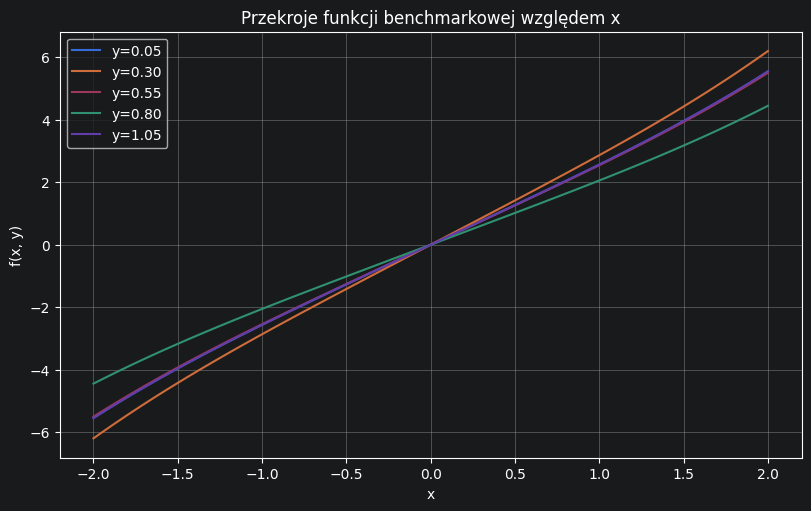

In [9]:
y_sections = np.linspace(Y_MIN, Y_MAX, 5)

fig, ax = plt.subplots(constrained_layout=True)
for y0 in y_sections:
    ax.plot(x, f_benchmark(x, y0), label=f"y={y0:.2f}")

ax.set_title("Przekroje funkcji benchmarkowej względem x")
ax.set_xlabel("x")
ax.set_ylabel("f(x, y)")
ax.legend()
plt.show()


### Interpretacja

Każda krzywa jest rosnąca, co jest zgodne z warunkiem:

$$
\frac{\partial f}{\partial x} = \Phi'(x) B(y) > 0
$$

ponieważ:
- `Phi'(x) > 0`,
- `B(y) > 0`.

W praktyce oznacza to, że benchmark jest dobry do testowania modeli z wymuszoną monotonicznością względem `x`.


## Wykres 2. Przekroje `y -> f(x, y)`

W przekrojach względem `y` widoczna jest sinusoidalno-gaussowska modulacja `B(y)`.
Jej amplituda zależy od `x`, ponieważ całość jest mnożona przez `Phi(x)`.

Dla `x > 0` czynnik `Phi(x)` jest dodatni, więc modulacja `B(y)` jest widoczna z dodatnim znakiem. Dla `x < 0` czynnik `Phi(x)` jest ujemny, więc przekrój względem `y` jest odwrócony. Dla `x = 0` cały przekrój spełnia:

$$
f(0, y) = 0.
$$

To ważne:
- funkcja nie jest czysto addytywna,
- zachodzi rzeczywista interakcja `x-y`,
- amplituda zmian w `y` rośnie wraz z bezwzględną skalą czynnika `Phi(x)`.


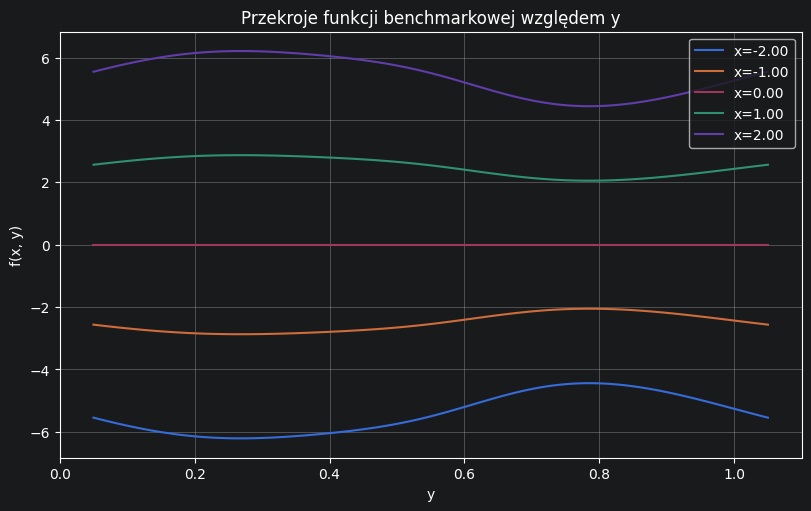

In [10]:
x_sections = [-2.0, -1.0, 0.0, 1.0, 2.0]

fig, ax = plt.subplots(constrained_layout=True)
for x0 in x_sections:
    ax.plot(y, f_benchmark(x0, y), label=f"x={x0:.2f}")

ax.set_title("Przekroje funkcji benchmarkowej względem y")
ax.set_xlabel("y")
ax.set_ylabel("f(x, y)")
ax.legend()
plt.show()


## Skalowanie kolorów na wykresach

W kolejnych mapach i powierzchniach 3D skala kolorów jest wyznaczana bezpośrednio z rzeczywistego zakresu wartości danej wielkości na siatce.

Dla pól nieujemnych, takich jak `std_z` i `df/dx`, używana jest skala sekwencyjna.  
Dla pól ze zmianą znaku, takich jak `f(x,y)`, `df/dy`, `d2f/dx2`, `d2f/dxdy` i `d2f/dy2`, używana jest skala rozbieżna wyśrodkowana w zerze. Dzięki temu znak i skala wartości są czytelne, a pasek kolorów odpowiada rzeczywistemu zakresowi danych.

## Wykres 3. Mapa konturowa

Mapa konturowa pozwala zobaczyć:
- globalny trend rosnący względem `x`,
- lokalne fale w kierunku `y`,
- brak degeneracji powierzchni do prostego modelu addytywnego.


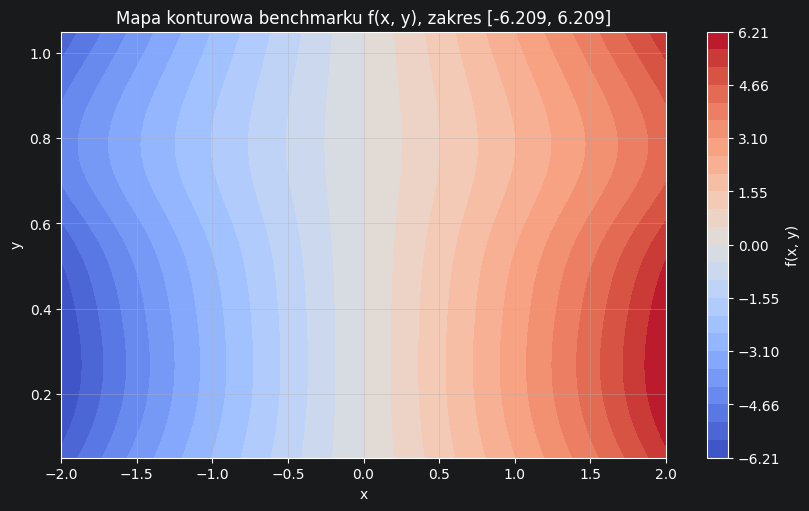

In [11]:
norm, cmap, levels, vmin, vmax = field_color_settings(Z, center_zero=True)

fig, ax = plt.subplots(constrained_layout=True)
contour = ax.contourf(X, Y, Z, levels=levels, cmap=cmap, norm=norm)
ax.set_title(f"Mapa konturowa benchmarku f(x, y), zakres {format_range(vmin, vmax)}")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(contour, ax=ax, label="f(x, y)")
plt.show()

## Dodatkowy wykres. Mapa konturowa `std_z`

Ta mapa pokazuje przestrzenny rozkład metrologicznej standardowej niepewności pomiaru wartości `z`.

`std_z` wynika z zakresowej specyfikacji niepewności dla mierzonej wartości `z`:

$$
\operatorname{std}_z
=
\frac{p_r |z| + o_r}{\sqrt{3}}.
$$

Największe wartości `std_z` pojawiają się tam, gdzie powierzchnia benchmarkowa ma największą wartość bezwzględną albo gdzie zmienia się zakres pomiarowy. W aktualnym benchmarku wartości `z` mieszczą się w pierwszym zakresie `_Z_RANGES`, dlatego mapa jest gładka i zdominowana przez składnik proporcjonalny do `abs(z)`.


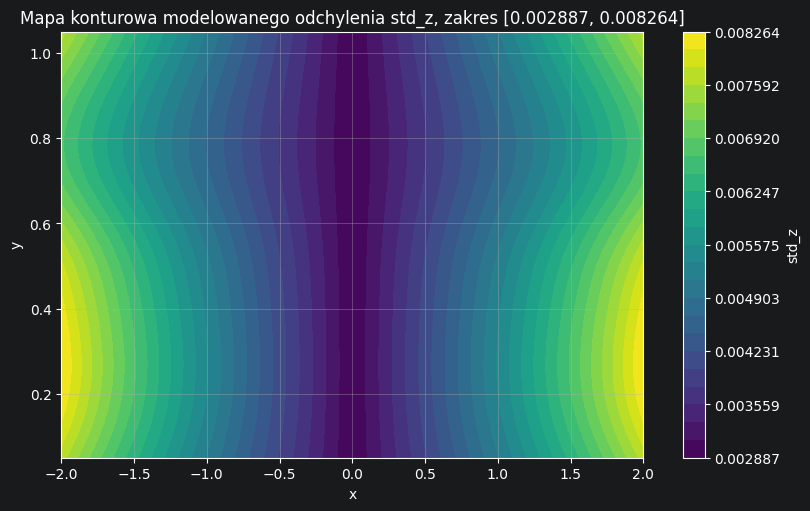

In [12]:
norm, cmap, levels, vmin, vmax = field_color_settings(STD_Z, center_zero=False)

fig, ax = plt.subplots(constrained_layout=True)
contour = ax.contourf(X, Y, STD_Z, levels=levels, cmap=cmap, norm=norm)
ax.set_title(f"Mapa konturowa modelowanego odchylenia std_z, zakres {format_range(vmin, vmax)}")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(contour, ax=ax, label="std_z")
plt.show()

## Wykres 4. Powierzchnia 3D

Na powierzchni 3D widać jednocześnie:
- trend w `x`,
- modulację w `y`,
- zmianę skali fal wraz z położeniem wzdłuż osi `x`.

Ten widok jest szczególnie przydatny przed dopasowaniem modelu 2D P-spline, bo daje intuicję, jak trudny jest benchmark.


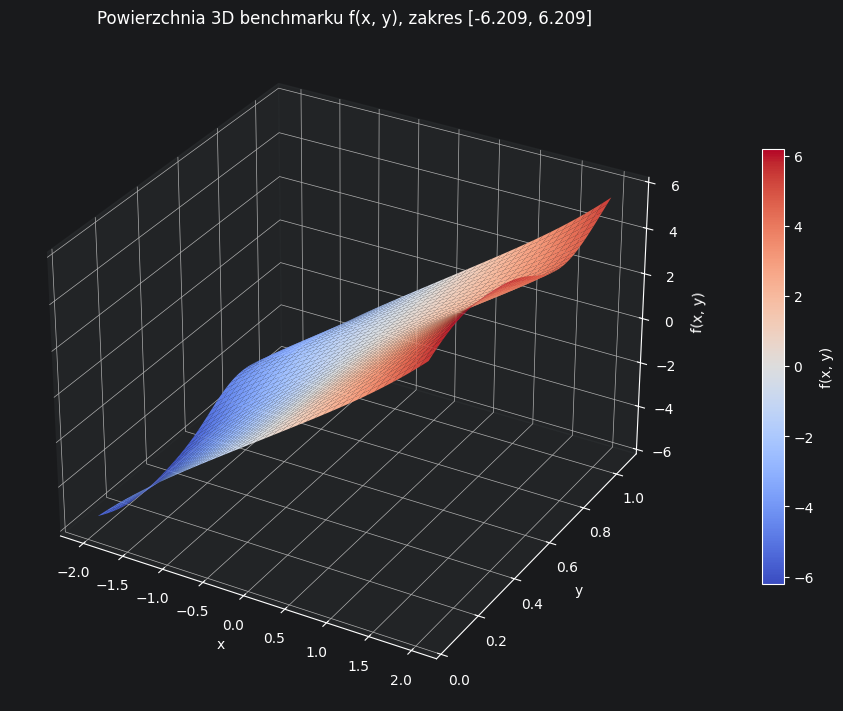

In [13]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

norm, cmap, levels, vmin, vmax = field_color_settings(Z, center_zero=True)

fig = plt.figure(constrained_layout=True, figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
surface = ax.plot_surface(X, Y, Z, linewidth=0, antialiased=True, cmap=cmap, norm=norm)

ax.set_title(f"Powierzchnia 3D benchmarku f(x, y), zakres {format_range(vmin, vmax)}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")
ax.set_zlim(vmin, vmax)
fig.colorbar(surface, ax=ax, shrink=0.65, pad=0.1, label="f(x, y)")
plt.show()

## Wykres 5. Powierzchnia 3D pochodnej względem x

Ten wykres pokazuje analityczną pochodną `df/dx`.
Jest to kluczowa wielkość, jeśli chcemy później testować modele, które mają:
- zachować monotoniczność,
- poprawnie odtwarzać tempo zmian wzdłuż osi `x`.


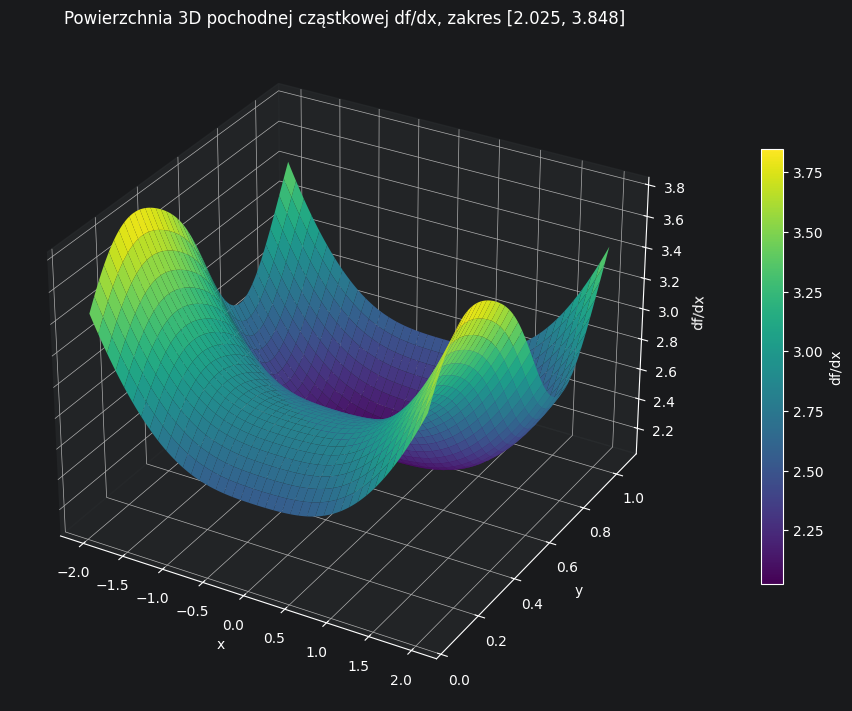

In [14]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

DFDX = dfdx_true(X, Y)
norm, cmap, levels, vmin, vmax = field_color_settings(DFDX, center_zero=False)

fig = plt.figure(constrained_layout=True, figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
surface = ax.plot_surface(X, Y, DFDX, linewidth=0, antialiased=True, cmap=cmap, norm=norm)

ax.set_title(f"Powierzchnia 3D pochodnej cząstkowej df/dx, zakres {format_range(vmin, vmax)}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("df/dx")
ax.set_zlim(vmin, vmax)
fig.colorbar(surface, ax=ax, shrink=0.65, pad=0.1, label="df/dx")
plt.show()

## Wykres 6. Powierzchnia 3D drugiej pochodnej względem x

Ta powierzchnia pokazuje analityczną drugą pochodną `d2f/dx2`.

Najważniejsza cecha nowego benchmarku:
- `d2f/dx2` jest gładna i łagodna,
- w punkcie `x = 0` znika,
- nie tworzy sztucznej, bardzo wąskiej warstwy przejściowej.

To sprawia, że benchmark lepiej nadaje się do walidacji stabilności rekonstrukcji krzywizny.


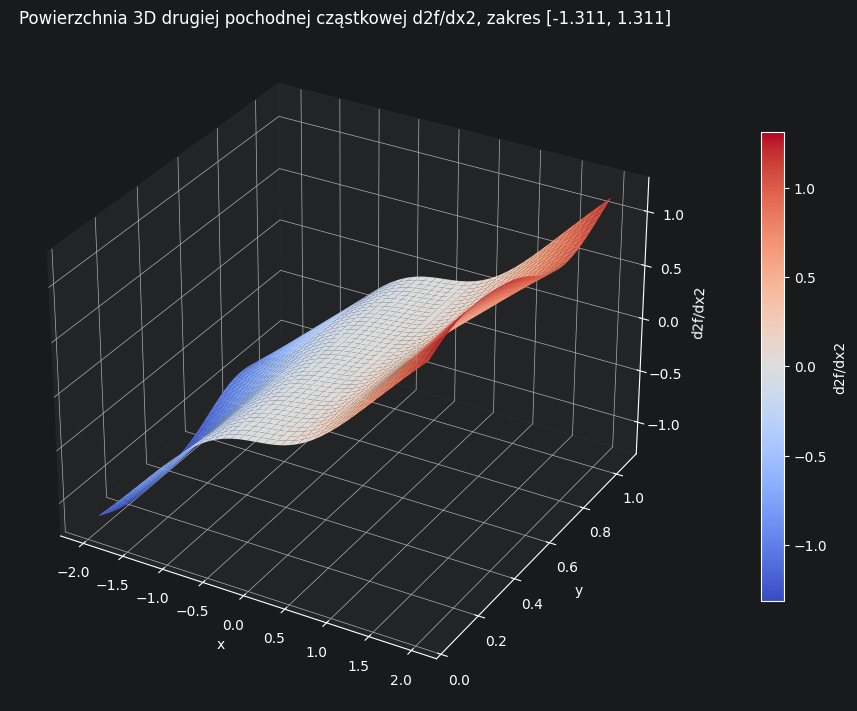

In [15]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

norm, cmap, levels, vmin, vmax = field_color_settings(D2FDX2, center_zero=True)

fig = plt.figure(constrained_layout=True, figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
surface = ax.plot_surface(X, Y, D2FDX2, linewidth=0, antialiased=True, cmap=cmap, norm=norm)

ax.set_title(f"Powierzchnia 3D drugiej pochodnej cząstkowej d2f/dx2, zakres {format_range(vmin, vmax)}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("d2f/dx2")
ax.set_zlim(vmin, vmax)
fig.colorbar(surface, ax=ax, shrink=0.7, pad=0.1, label="d2f/dx2")
plt.show()

## Wykres 7. Powierzchnia 3D pochodnej względem y

Ten wykres pokazuje analityczną pochodną `df/dy`.

Interpretacja:
- `df/dy` opisuje lokalną czułość funkcji na zmiany zmiennej `y`,
- znak pochodnej informuje, czy przy ustalonym `x` funkcja lokalnie rośnie, czy maleje względem `y`,
- wartość bezwzględna `df/dy` mówi o sile tych zmian.

W tym benchmarku pochodna po `y` nie jest monotoniczna. To jest celowe:
- monotoniczność wymuszamy tylko względem `x`,
- natomiast względem `y` dopuszczamy bardziej złożone zachowanie,
- dzięki temu benchmark lepiej testuje anizotropię i zdolność modelu do odtwarzania lokalnej struktury powierzchni.


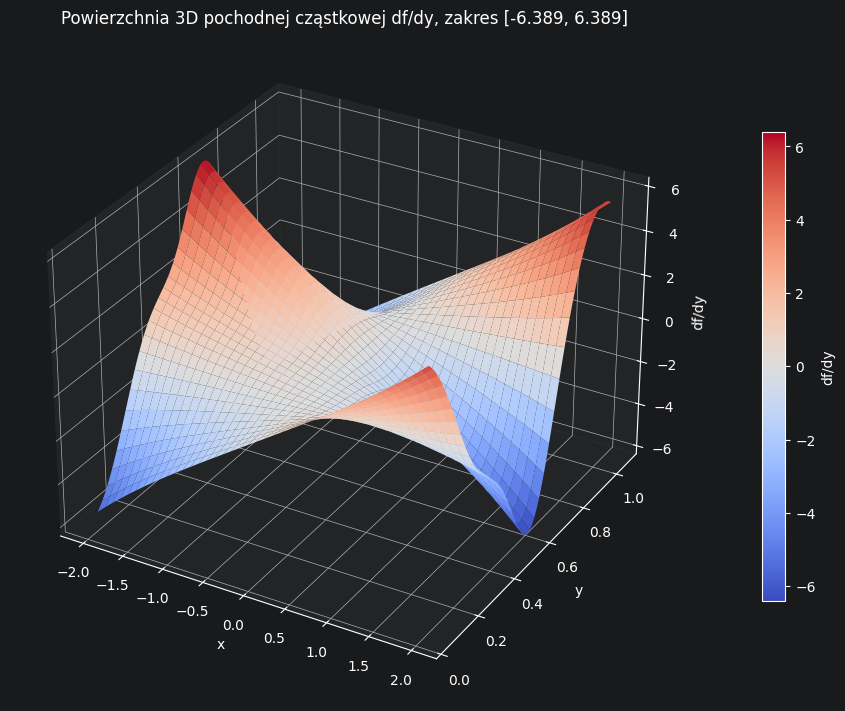

In [16]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

norm, cmap, levels, vmin, vmax = field_color_settings(DFDY, center_zero=True)

fig = plt.figure(constrained_layout=True, figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
surface = ax.plot_surface(X, Y, DFDY, linewidth=0, antialiased=True, cmap=cmap, norm=norm)

ax.set_title(f"Powierzchnia 3D pochodnej cząstkowej df/dy, zakres {format_range(vmin, vmax)}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("df/dy")
ax.set_zlim(vmin, vmax)
fig.colorbar(surface, ax=ax, shrink=0.7, pad=0.1, label="df/dy")
plt.show()

## Wykres 8. Powierzchnia 3D drugiej pochodnej względem y

Ta powierzchnia pokazuje analityczną drugą pochodną `d2f/dy2`.

Interpretacja:
- `d2f/dy2` opisuje lokalną krzywiznę powierzchni w kierunku osi `y`,
- dodatnie wartości oznaczają lokalną wypukłość względem `y`,
- ujemne wartości oznaczają lokalną wklęsłość względem `y`.

W tym benchmarku `d2f/dy2` pochodzi z połączenia:
- składnika sinusoidalnego,
- oraz lokalnego składnika gaussowskiego.

Dzięki temu krzywizna względem `y` nie jest trywialna, ale pozostaje:
- jawna analitycznie,
- gładka,
- stabilna numerycznie.

To czyni ją dobrym benchmarkiem do oceny jakości rekonstrukcji drugiej pochodnej przez modele 2D P-spline.


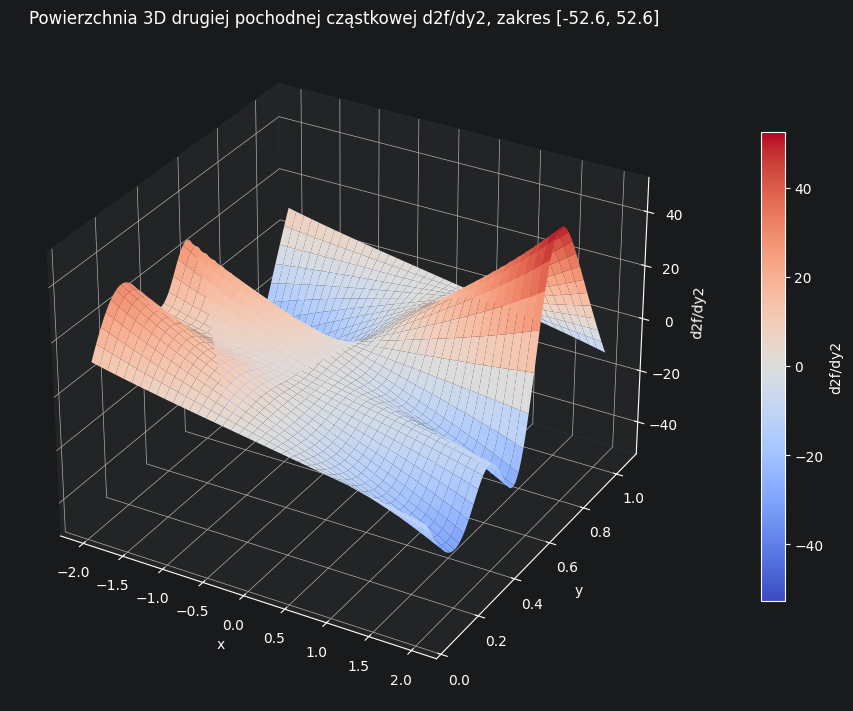

In [17]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

norm, cmap, levels, vmin, vmax = field_color_settings(D2FDY2, center_zero=True)

fig = plt.figure(constrained_layout=True, figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
surface = ax.plot_surface(X, Y, D2FDY2, linewidth=0, antialiased=True, cmap=cmap, norm=norm)

ax.set_title(f"Powierzchnia 3D drugiej pochodnej cząstkowej d2f/dy2, zakres {format_range(vmin, vmax)}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("d2f/dy2")
ax.set_zlim(vmin, vmax)
fig.colorbar(surface, ax=ax, shrink=0.7, pad=0.1, label="d2f/dy2")
plt.show()

## Kontrola monotoniczności

Sprawdzamy numerycznie, czy minimum pochodnej po `x` na siatce jest dodatnie.
Jeśli tak, to funkcja jest ściśle rosnąca względem `x` w całej analizowanej dziedzinie.


In [18]:
DFDX = dfdx_true(X, Y)
B_Y = basis_y(Y)

print(f"min df/dx: {DFDX.min():.8f}")
print(f"max df/dx: {DFDX.max():.8f}")
print(f"min B(y): {B_Y.min():.8f}")
print(f"max B(y): {B_Y.max():.8f}")

if np.all(np.isfinite(DFDX)) and DFDX.min() > 0.0:
    print("OK: funkcja jest ściśle rosnąca względem x na całej siatce.")
else:
    raise ValueError("Błąd: warunek monotoniczności względem x nie jest spełniony.")


min df/dx: 2.02541958
max df/dx: 3.84769855
min B(y): 1.68784965
max B(y): 2.36039861
OK: funkcja jest ściśle rosnąca względem x na całej siatce.


## Kontrola pochodnej drugiego rzędu względem x

Sprawdzamy zgodność analitycznej pochodnej `d2fdx2_true` z centralnym przybliżeniem różnicowym liczonym na podstawie `dfdx_true`.

To klasyczny test poprawności implementacji wzorów analitycznych.


In [19]:
x_test = np.linspace(X_MIN, X_MAX, 201)
y_test = np.array([Y_MIN, 0.5 * (Y_MIN + Y_MAX), Y_MAX])
h = 1e-5

max_abs_errors = []

for y0 in y_test:
    dfdx_plus = dfdx_true(x_test + h, y0)
    dfdx_minus = dfdx_true(x_test - h, y0)
    d2fdx2_num = (dfdx_plus - dfdx_minus) / (2.0 * h)
    d2fdx2_an = d2fdx2_true(x_test, y0)

    max_abs_error = np.max(np.abs(d2fdx2_num - d2fdx2_an))
    max_abs_errors.append(max_abs_error)

    print(f"y={y0:.4f}, max |d2fdx2_num - d2fdx2_true| = {max_abs_error:.6e}")

if max(max_abs_errors) < 1e-5:
    print("OK: d2fdx2_true jest zgodna z kontrolą różnicową.")
else:
    raise ValueError("Błąd: d2fdx2_true nie zgadza się z kontrolą różnicową.")

y=0.0500, max |d2fdx2_num - d2fdx2_true| = 4.747935e-11
y=0.5500, max |d2fdx2_num - d2fdx2_true| = 4.539477e-11
y=1.0500, max |d2fdx2_num - d2fdx2_true| = 5.314935e-11
OK: d2fdx2_true jest zgodna z kontrolą różnicową.


## Kontrola warunku zerowego

Sprawdzamy warunek konstrukcyjny:

$$
f(0,y)=0
$$

dla każdego punktu siatki w kierunku `y`.

W tym benchmarku warunek ten wynika bezpośrednio z faktu, że:

$$
\Phi(0)=0.
$$


In [20]:
zero_line_y = np.linspace(Y_MIN, Y_MAX, 401)
zero_line = f_benchmark(np.zeros_like(zero_line_y), zero_line_y)
max_abs_zero_line = np.max(np.abs(zero_line))

print(f"max |f(0, y)|: {max_abs_zero_line:.12e}")

if max_abs_zero_line < 1e-12:
    print("OK: warunek f(0, y) = 0 jest spełniony numerycznie.")
else:
    raise ValueError("Błąd: warunek f(0, y) = 0 nie jest spełniony.")


max |f(0, y)|: 0.000000000000e+00
OK: warunek f(0, y) = 0 jest spełniony numerycznie.


## Maksima, minima i zgodność z monotonicznością

Ponieważ:

$$
\frac{\partial f}{\partial x}>0
$$

w całej dziedzinie, funkcja nie może mieć klasycznych wewnętrznych lokalnych maksimów ani minimów pełnej powierzchni 2D. W takim punkcie musiałoby zachodzić:

$$
\nabla f=0,
$$

co jest sprzeczne z dodatnią pochodną względem `x`.

Maksima i minima należy interpretować tutaj w sensie:

- ekstremów globalnych na brzegu prostokątnej dziedziny,
- ekstremów przekrojów `f(x0, y)` względem `y`,
- grzbietów i dolin przekrojowych,
- punktów lokalnie dużej krzywizny względem `y`.

Bogatsza struktura względem `y` wynika z tego, że `B(y)` zawiera:

- składnik sinusoidalny,
- lokalne zaburzenie gaussowskie.

W efekcie powierzchnia jest jednocześnie:

- monotoniczna względem `x`,
- lokalnie zróżnicowana względem `y`,
- odpowiednia jako benchmark dla modeli z ograniczeniami kształtu.


## Kontrola pochodnej pierwszego rzędu względem y

Sprawdzamy zgodność analitycznej pochodnej `dfdy_true` z centralnym przybliżeniem różnicowym funkcji `f_benchmark` względem `y`.


In [21]:
x_test = np.array([X_MIN, 0.0, X_MAX])
y_test = np.linspace(Y_MIN + 1e-4, Y_MAX - 1e-4, 201)
h = 1e-5

max_abs_errors = []

for x0 in x_test:
    f_plus = f_benchmark(x0, y_test + h)
    f_minus = f_benchmark(x0, y_test - h)
    dfdy_num = (f_plus - f_minus) / (2.0 * h)
    dfdy_an = dfdy_true(x0, y_test)

    max_abs_error = np.max(np.abs(dfdy_num - dfdy_an))
    max_abs_errors.append(max_abs_error)

    print(f"x={x0:.4f}, max |dfdy_num - dfdy_true| = {max_abs_error:.6e}")

if max(max_abs_errors) < 1e-5:
    print("OK: dfdy_true jest zgodna z kontrolą różnicową.")
else:
    raise ValueError("Błąd: dfdy_true nie zgadza się z kontrolą różnicową.")


x=-2.0000, max |dfdy_num - dfdy_true| = 9.583687e-09
x=0.0000, max |dfdy_num - dfdy_true| = 0.000000e+00
x=2.0000, max |dfdy_num - dfdy_true| = 9.583687e-09
OK: dfdy_true jest zgodna z kontrolą różnicową.


## Kontrola pochodnej drugiego rzędu względem y

Sprawdzamy zgodność analitycznej pochodnej `d2fdy2_true` z centralnym przybliżeniem różnicowym pochodnej `dfdy_true` względem `y`.


In [22]:
x_test = np.array([X_MIN, -1.0, 0.0, 1.0, X_MAX])
y_test = np.linspace(Y_MIN + 1e-4, Y_MAX - 1e-4, 201)
h = 1e-5

max_abs_errors = []

for x0 in x_test:
    dfdy_plus = dfdy_true(x0, y_test + h)
    dfdy_minus = dfdy_true(x0, y_test - h)
    d2fdy2_num = (dfdy_plus - dfdy_minus) / (2.0 * h)
    d2fdy2_an = d2fdy2_true(x0, y_test)

    max_abs_error = np.max(np.abs(d2fdy2_num - d2fdy2_an))
    max_abs_errors.append(max_abs_error)

    print(f"x={x0:.4f}, max |d2fdy2_num - d2fdy2_true| = {max_abs_error:.6e}")

if max(max_abs_errors) < 1e-4:
    print("OK: d2fdy2_true jest zgodna z kontrolą różnicową.")
else:
    raise ValueError("Błąd: d2fdy2_true nie zgadza się z kontrolą różnicową.")


x=-2.0000, max |d2fdy2_num - d2fdy2_true| = 1.197596e-07
x=-1.0000, max |d2fdy2_num - d2fdy2_true| = 5.536161e-08
x=0.0000, max |d2fdy2_num - d2fdy2_true| = 0.000000e+00
x=1.0000, max |d2fdy2_num - d2fdy2_true| = 5.536161e-08
x=2.0000, max |d2fdy2_num - d2fdy2_true| = 1.197596e-07
OK: d2fdy2_true jest zgodna z kontrolą różnicową.


## Kontrola pochodnej mieszanej

Sprawdzamy zgodność analitycznej pochodnej mieszanej `d2fdxdy_true` z centralnym przybliżeniem różnicowym pochodnej `dfdx_true` względem `y`.


In [23]:
x_test = np.linspace(X_MIN, X_MAX, 101)
y_test_values = np.array([Y_MIN + 1e-4, 0.5 * (Y_MIN + Y_MAX), Y_MAX - 1e-4])
h = 1e-5

max_abs_errors = []

for y0 in y_test_values:
    dfdx_plus = dfdx_true(x_test, y0 + h)
    dfdx_minus = dfdx_true(x_test, y0 - h)
    d2fdxdy_num = (dfdx_plus - dfdx_minus) / (2.0 * h)
    d2fdxdy_an = d2fdxdy_true(x_test, y0)

    max_abs_error = np.max(np.abs(d2fdxdy_num - d2fdxdy_an))
    max_abs_errors.append(max_abs_error)

    print(f"y={y0:.4f}, max |d2fdxdy_num - d2fdxdy_true| = {max_abs_error:.6e}")

if max(max_abs_errors) < 1e-5:
    print("OK: d2fdxdy_true jest zgodna z kontrolą różnicową.")
else:
    raise ValueError("Błąd: d2fdxdy_true nie zgadza się z kontrolą różnicową.")


y=0.0501, max |d2fdxdy_num - d2fdxdy_true| = 2.176860e-09
y=0.5500, max |d2fdxdy_num - d2fdxdy_true| = 2.225894e-09
y=1.0499, max |d2fdxdy_num - d2fdxdy_true| = 2.290467e-09
OK: d2fdxdy_true jest zgodna z kontrolą różnicową.


## Wykres 9. Powierzchnia 3D pochodnej mieszanej

Ta powierzchnia pokazuje analityczną pochodną mieszaną `d2f/dxdy`.

Dla funkcji rozdzielonej:

$$
f(x,y)=\Phi(x)B(y)
$$

pochodna mieszana ma postać:

$$
\frac{\partial^2 f}{\partial x\partial y}
=
\Phi'(x)B'(y).
$$

Wykres pokazuje, jak lokalne tempo wzrostu względem `x` zmienia się w kierunku `y`.


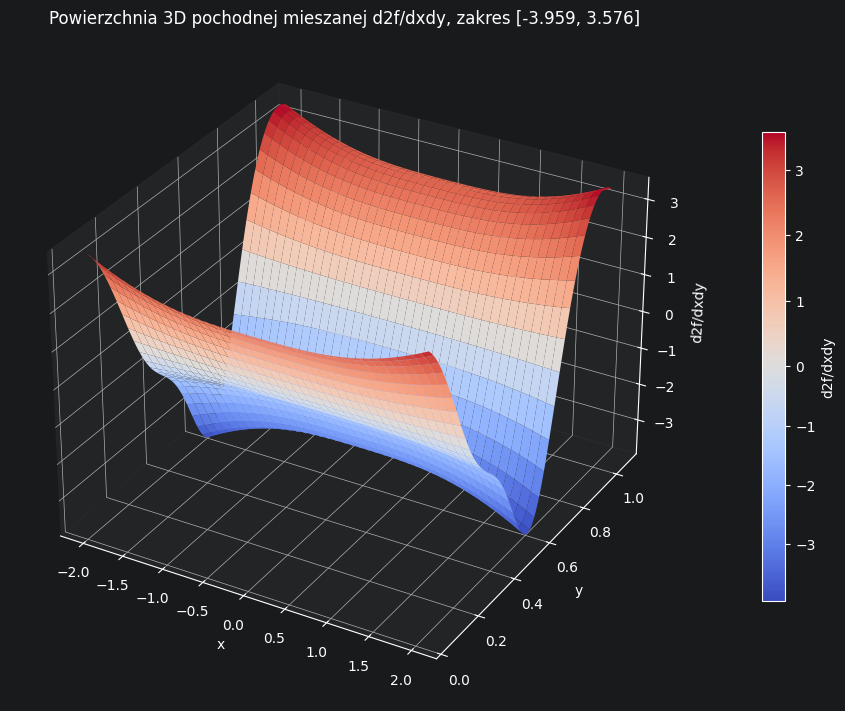

In [24]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

norm, cmap, levels, vmin, vmax = field_color_settings(D2FDXDY, center_zero=True)

fig = plt.figure(constrained_layout=True, figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
surface = ax.plot_surface(X, Y, D2FDXDY, linewidth=0, antialiased=True, cmap=cmap, norm=norm)

ax.set_title(f"Powierzchnia 3D pochodnej mieszanej d2f/dxdy, zakres {format_range(vmin, vmax)}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("d2f/dxdy")
ax.set_zlim(vmin, vmax)
fig.colorbar(surface, ax=ax, shrink=0.7, pad=0.1, label="d2f/dxdy")
plt.show()

Uwaga: plik CSV jest zapisywany względem aktualnego katalogu roboczego kernela. Ścieżka absolutna jest wypisywana przez notebook po zapisie pliku.


## Podsumowanie

Ten notebook definiuje edukacyjnie przejrzysty benchmark 2D:

$$
f(x,y)=\Phi(x)B(y).
$$

Najważniejsze własności funkcji:

- `f(0, y) = 0` dla każdego `y`,
- funkcja jest gładka i stabilna numerycznie,
- funkcja jest ściśle rosnąca względem `x`,
- zmienna `x` obejmuje wartości ujemne i dodatnie,
- zmienna `y` pozostaje dodatnia w całej dziedzinie,
- funkcja zawiera interakcję między `x` i `y`,
- część `B(y)` wprowadza oscylacje oraz lokalny składnik Gaussa,
- pochodne pierwszego i drugiego rzędu są dane analitycznie.

Najważniejsze własności danych wyjściowych:

- CSV zawiera współrzędne, wartość wzorcową `true_z`, zaszumowaną obserwację `observed_z`, `std_z`, gradient i pochodne drugiego rzędu,
- `observed_z` jest losowane z rozkładu $\mathcal N(\texttt{true\_z},\texttt{std\_z}^2)$,
- `std_z` modeluje metrologiczne odchylenie standardowe pomiaru `z`,
- `std_z` jest liczone jako błąd graniczny przyrządu podzielony przez `sqrt(3)`,
- pomocnicze składniki wewnętrzne, takie jak `true_phi_x`, `true_basis_y` i `true_gaussian_y`, nie są zapisywane do CSV.

Notebook zawiera diagnostykę:

- kontrolę skończoności wartości,
- kontrolę dodatniości, skończoności i zgodności modelu `std_z` z relacją `error_z / sqrt(3)`,
- kontrolę zgodności zaszumowanej obserwacji `observed_z` z modelem normalnym,
- kontrolę monotoniczności względem `x`,
- kontrolę warunku zerowego `f(0, y)=0`,
- kontrolę różnicową `d2f/dx2`,
- kontrolę różnicową `df/dy`,
- kontrolę różnicową `d2f/dy2`,
- kontrolę różnicową `d2f/dxdy`.

Ten notebook nie dopasowuje jeszcze modelu P-spline. Przygotowuje funkcję benchmarkową, zaszumowane obserwacje, wartości referencyjne i model niepewności, które mogą zostać użyte w kolejnych notebookach.
